# Descirpitve Analysys of the Final Dataset

This notebook redoes the original final-dataset EDA as a full descriptive analysis notebook.

The descriptive analysis is designed to support the final modeling choice:

`log(boxOffice) ~ audienceScore + initial_combined_sentiment_score + log_initial_review_count + initial_sentiment_x_log_review_count`

The notebook covers:
- dataset shape and structure
- variable description and data quality
- univariate analysis
- bivariate analysis
- grouped descriptive summaries
- focused analysis of the final model variables

This notebook is descriptive only. It does not fit the final regression model.


## 1. Setup and Load Data


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)


def resolve_data_path() -> Path:
    candidates = [Path.cwd(), Path.cwd().parent]
    for base in candidates:
        candidate = base / 'data' / 'final' / 'final.csv'
        if candidate.exists():
            return candidate
    raise FileNotFoundError('Could not find data/final/final.csv from the current working directory.')


DATA_PATH = resolve_data_path()
df = pd.read_csv(DATA_PATH)

FINAL_MODEL_VARS = [
    'audienceScore',
    'initial_combined_sentiment_score',
    'log_initial_review_count',
    'initial_sentiment_x_log_review_count',
]

print(f'Data path: {DATA_PATH}')
print(f'Dataset shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns')


Data path: c:\Users\dinuka\Documents\movie sentiment\data\final\final.csv
Dataset shape: 3,357 rows x 27 columns


## 2. Dataset Shape, Structure, and First Look


In [2]:
overview = pd.DataFrame({
    'column': df.columns,
    'dtype': [str(df[col].dtype) for col in df.columns],
    'non_null_count': [df[col].notna().sum() for col in df.columns],
    'missing_count': [df[col].isna().sum() for col in df.columns],
    'missing_pct': [df[col].isna().mean() * 100 for col in df.columns],
    'n_unique': [df[col].nunique(dropna=True) for col in df.columns],
})

display(overview)
display(df.head())


,column,dtype,non_null_count,missing_count,missing_pct,n_unique
0,id,str,3357,0,0.0000,3357
1,title,str,3357,0,0.0000,3357
2,audienceScore,float64,3357,0,0.0000,88
3,tomatoMeter,float64,3357,0,0.0000,101
4,rating,str,3357,0,0.0000,4
5,ratingContents,str,3357,0,0.0000,2685
6,releaseDateTheaters,str,3357,0,0.0000,1319
7,releaseDateStreaming,str,3357,0,0.0000,1263
8,runtimeMinutes,float64,3357,0,0.0000,110
9,genre,str,3357,0,0.0000,544


,id,title,audienceScore,tomatoMeter,rating,ratingContents,releaseDateTheaters,releaseDateStreaming,runtimeMinutes,genre,originalLanguage,director,writer,boxOffice,distributor,soundMix,initial_review_count,initial_positive_review_count,initial_negative_review_count,initial_top_critic_review_count,initial_positive_review_ratio,initial_combined_sentiment_score,initial_combined_sentiment_label,log_initial_review_count,initial_sentiment_x_log_review_count,first_review_date,last_review_date_in_window
0,10_cloverfield_lane,10 Cloverfield Lane,79.0000,90.0000,PG-13,"['Frightening Sequences', 'Brief Language', 'S...",2016-03-11,2016-06-14,103.0000,Mystery & thriller,English,Dan Trachtenberg,"Josh Campbell,Matthew Stuecken,Damien Chazelle",72.1000,Paramount Pictures,"Dolby Digital, Dolby Atmos, Datasat",98,86,12,21,0.8776,0.7419,positive,4.5951,3.4093,2016-03-11,2016-03-20
1,10_years,10 Years,40.0000,60.0000,PG-13,"['Drug Use', 'Alcohol Abuse', 'Language', 'Som...",2012-09-14,2012-12-18,100.0000,Comedy,English,Jamie Linden,Jamie Linden,0.2011,Anchor Bay,NaN,30,15,15,12,0.5000,0.0278,mixed,3.4340,0.0954,2012-09-14,2012-09-22
2,10000_bc,"10,000 B.C.",37.0000,9.0000,PG-13,"['Violence', 'Sequences of Intense Action']",2008-03-07,2008-06-24,109.0000,"Adventure, Action, Drama",English,Roland Emmerich,"Roland Emmerich,Harald Kloser",94.8000,Warner Bros.,"Dolby SRD, DTS, SDDS",78,5,73,30,0.0641,-0.8602,negative,4.3694,-3.7587,2008-03-07,2008-03-16
3,12_strong,12 Strong,62.0000,50.0000,R,"['War Violence', 'Language Throughout']",2018-01-19,2018-05-01,130.0000,"War, Drama",English,Nicolai Fuglsig,"Ted Tally,Peter Craig",44.3000,Warner Bros. Pictures,Dolby Atmos,60,36,24,19,0.6000,0.1799,mixed,4.1109,0.7394,2018-01-19,2018-01-28
4,12_years_a_slave,12 Years a Slave,90.0000,95.0000,R,"['Some Nudity', 'Brief Sexuality', 'Violence/C...",2013-10-18,2014-03-04,134.0000,"History, Drama, Biography",English,Steve McQueen,John Ridley,56.7000,Fox Searchlight,"Datasat, Dolby Digital",53,51,2,16,0.9623,0.9344,positive,3.9890,3.7274,2013-10-18,2013-10-26


## 3. Variable Description

The table below organizes the main variables into descriptive roles so the dataset is easier to read before plotting.


In [3]:
variable_description = pd.DataFrame([
    ('id', 'Identifier', 'Unique movie identifier'),
    ('title', 'Identifier', 'Movie title'),
    ('audienceScore', 'Final model predictor', 'Audience score from Rotten Tomatoes'),
    ('boxOffice', 'Outcome', 'Box office outcome in the final dataset'),
    ('tomatoMeter', 'Context variable', 'Critic score from Rotten Tomatoes'),
    ('rating', 'Categorical context', 'MPAA-style content rating'),
    ('genre', 'Categorical context', 'Movie genre string'),
    ('originalLanguage', 'Categorical context', 'Original movie language'),
    ('distributor', 'Categorical context', 'Distributor name'),
    ('runtimeMinutes', 'Numeric context', 'Runtime in minutes'),
    ('initial_review_count', 'Derived reaction feature', 'Number of reviews observed in the initial window'),
    ('initial_positive_review_count', 'Derived reaction feature', 'Positive reviews in the initial window'),
    ('initial_negative_review_count', 'Derived reaction feature', 'Negative reviews in the initial window'),
    ('initial_top_critic_review_count', 'Derived reaction feature', 'Top critic reviews in the initial window'),
    ('initial_positive_review_ratio', 'Derived reaction feature', 'Share of positive reviews in the initial window'),
    ('initial_combined_sentiment_score', 'Final model predictor', 'Combined early sentiment score'),
    ('initial_combined_sentiment_label', 'Grouped sentiment label', 'Categorical sentiment class derived from the score'),
    ('log_initial_review_count', 'Final model predictor', 'Logged version of initial review count'),
    ('initial_sentiment_x_log_review_count', 'Final model predictor', 'Interaction between sentiment and logged review count'),
    ('first_review_date', 'Time context', 'First review date in the initial review window'),
    ('last_review_date_in_window', 'Time context', 'Last review date retained in the initial window'),
], columns=['variable', 'role', 'description'])

display(variable_description)


,variable,role,description
0,id,Identifier,Unique movie identifier
1,title,Identifier,Movie title
2,audienceScore,Final model predictor,Audience score from Rotten Tomatoes
3,boxOffice,Outcome,Box office outcome in the final dataset
4,tomatoMeter,Context variable,Critic score from Rotten Tomatoes
5,rating,Categorical context,MPAA-style content rating
6,genre,Categorical context,Movie genre string
7,originalLanguage,Categorical context,Original movie language
8,distributor,Categorical context,Distributor name
9,runtimeMinutes,Numeric context,Runtime in minutes


## 4. Data Quality and Preparation

This section checks missing values, duplicates, and the availability of the variables needed for the final specification.


In [4]:
analysis_df = df.copy()
analysis_df['boxOffice'] = pd.to_numeric(analysis_df['boxOffice'], errors='coerce')
analysis_df['log_boxOffice'] = np.nan
positive_box_office_mask = analysis_df['boxOffice'] > 0
analysis_df.loc[positive_box_office_mask, 'log_boxOffice'] = np.log(analysis_df.loc[positive_box_office_mask, 'boxOffice'])
analysis_df['release_year'] = pd.to_datetime(analysis_df['releaseDateTheaters'], errors='coerce').dt.year
analysis_df['primary_genre'] = analysis_df['genre'].fillna('Unknown').astype(str).str.split(',').str[0].str.strip()

missingness = pd.DataFrame({
    'missing_count': analysis_df.isna().sum(),
    'missing_pct': analysis_df.isna().mean() * 100,
}).sort_values(['missing_count', 'missing_pct'], ascending=False)

duplicate_id_count = int(analysis_df['id'].duplicated().sum())
non_positive_box_office = int((analysis_df['boxOffice'] <= 0).fillna(False).sum())

final_spec_cols = ['log_boxOffice'] + FINAL_MODEL_VARS
final_model_completeness = pd.DataFrame({
    'non_null_count': analysis_df[final_spec_cols].notna().sum(),
    'missing_count': analysis_df[final_spec_cols].isna().sum(),
    'missing_pct': analysis_df[final_spec_cols].isna().mean() * 100,
})

print(f'Duplicate id rows: {duplicate_id_count}')
print(f'Rows with non-positive boxOffice values: {non_positive_box_office}')
print(f'Rows available for the final specification: {analysis_df[final_spec_cols].dropna().shape[0]:,}')

display(missingness)
display(final_model_completeness)


Duplicate id rows: 0
Rows with non-positive boxOffice values: 1
Rows available for the final specification: 3,356


,missing_count,missing_pct
soundMix,1221,36.3718
log_boxOffice,1,0.0298
id,0,0.0000
title,0,0.0000
audienceScore,0,0.0000
tomatoMeter,0,0.0000
rating,0,0.0000
ratingContents,0,0.0000
releaseDateTheaters,0,0.0000
releaseDateStreaming,0,0.0000


,non_null_count,missing_count,missing_pct
log_boxOffice,3356,1,0.0298
audienceScore,3357,0,0.0000
initial_combined_sentiment_score,3357,0,0.0000
log_initial_review_count,3357,0,0.0000
initial_sentiment_x_log_review_count,3357,0,0.0000


## 5. Numeric Descriptive Summary

The summary below covers the main outcome, the final-model variables, and a few context variables that help interpret the dataset.


In [5]:
summary_cols = [
    'boxOffice',
    'log_boxOffice',
    'audienceScore',
    'tomatoMeter',
    'runtimeMinutes',
    'initial_review_count',
    'initial_positive_review_ratio',
    'initial_combined_sentiment_score',
    'log_initial_review_count',
    'initial_sentiment_x_log_review_count',
]

summary_table = analysis_df[summary_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
summary_table['skew'] = analysis_df[summary_cols].skew(numeric_only=True)
summary_table['missing_pct'] = analysis_df[summary_cols].isna().mean() * 100

display(summary_table)


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew,missing_pct
boxOffice,"3,357.0000",50.0471,77.1606,0.0000,0.0505,0.2534,5.2000,24.4000,60.0000,189.5600,376.7920,858.4000,3.6462,0.0000
log_boxOffice,"3,356.0000",2.6963,2.0309,-13.1224,-2.9732,-1.3697,1.6487,3.1946,4.0943,5.2449,5.9317,6.7551,-1.0760,0.0298
audienceScore,"3,357.0000",60.9556,18.8425,10.0000,21.0000,30.0000,46.0000,62.0000,76.0000,90.0000,95.0000,99.0000,-0.1396,0.0000
tomatoMeter,"3,357.0000",54.2687,27.2853,0.0000,4.0000,10.0000,31.0000,55.0000,79.0000,93.0000,97.0000,100.0000,-0.1559,0.0000
runtimeMinutes,"3,357.0000",108.0947,17.2432,66.0000,81.0000,86.0000,96.0000,105.0000,117.0000,140.0000,161.0000,223.0000,1.0984,0.0000
initial_review_count,"3,357.0000",56.0974,27.5638,21.0000,21.0000,23.0000,34.0000,51.0000,72.0000,105.0000,149.0000,192.0000,1.2131,0.0000
initial_positive_review_ratio,"3,357.0000",0.5331,0.2804,0.0000,0.0267,0.0857,0.2903,0.5397,0.7816,0.9524,1.0000,1.0000,-0.0982,0.0000
initial_combined_sentiment_score,"3,357.0000",0.0588,0.5625,-1.0000,-0.9432,-0.8307,-0.4286,0.0667,0.5556,0.8976,1.0000,1.0000,-0.0795,0.0000
log_initial_review_count,"3,357.0000",3.9362,0.4658,3.0910,3.0910,3.1781,3.5553,3.9512,4.2905,4.6634,5.0106,5.2627,0.0802,0.0000
initial_sentiment_x_log_review_count,"3,357.0000",0.2348,2.1989,-4.1744,-3.7147,-3.1961,-1.6854,0.2598,2.1643,3.5354,4.0937,4.8481,-0.0583,0.0000


## 6. Categorical Descriptive Summary

These tables show the composition of the dataset across key categorical variables.


In [6]:
def frequency_table(series, top_n=10):
    counts = series.fillna('Missing').value_counts(dropna=False).head(top_n)
    return pd.DataFrame({
        'count': counts,
        'pct': counts / len(series) * 100,
    })

for col in ['rating', 'initial_combined_sentiment_label', 'primary_genre', 'originalLanguage', 'distributor']:
    print(f'\nTop categories for {col}')
    display(frequency_table(analysis_df[col], top_n=10))



Top categories for rating


,count,pct
rating,,
R,1535,45.7254
PG-13,1356,40.3932
PG,465,13.8517
NC-17,1,0.0298



Top categories for initial_combined_sentiment_label


,count,pct
initial_combined_sentiment_label,,
positive,1482,44.1466
negative,1222,36.4015
mixed,653,19.4519



Top categories for primary_genre


,count,pct
primary_genre,,
Comedy,728,21.6860
Drama,483,14.3878
Action,348,10.3664
Kids & family,276,8.2216
Mystery & thriller,265,7.8940
Romance,258,7.6854
Horror,246,7.3280
Sci-fi,145,4.3193
Crime,108,3.2172



Top categories for originalLanguage


,count,pct
originalLanguage,,
English,3231,96.2466
English (United Kingdom),30,0.8937
French (France),16,0.4766
Chinese,15,0.4468
French (Canada),8,0.2383
Japanese,7,0.2085
Spanish,7,0.2085
German,4,0.1192
Spanish (Spain),4,0.1192



Top categories for distributor


,count,pct
distributor,,
Warner Bros. Pictures,280,8.3408
Universal Pictures,279,8.3110
20th Century Fox,232,6.9109
Paramount Pictures,220,6.5535
Sony Pictures Entertainment,182,5.4215
Lionsgate Films,157,4.6768
Focus Features,122,3.6342
Sony Pictures Classics,106,3.1576
Walt Disney,101,3.0086


## 7. Univariate Analysis

This section visualizes the distributions of the outcome and the main explanatory variables.


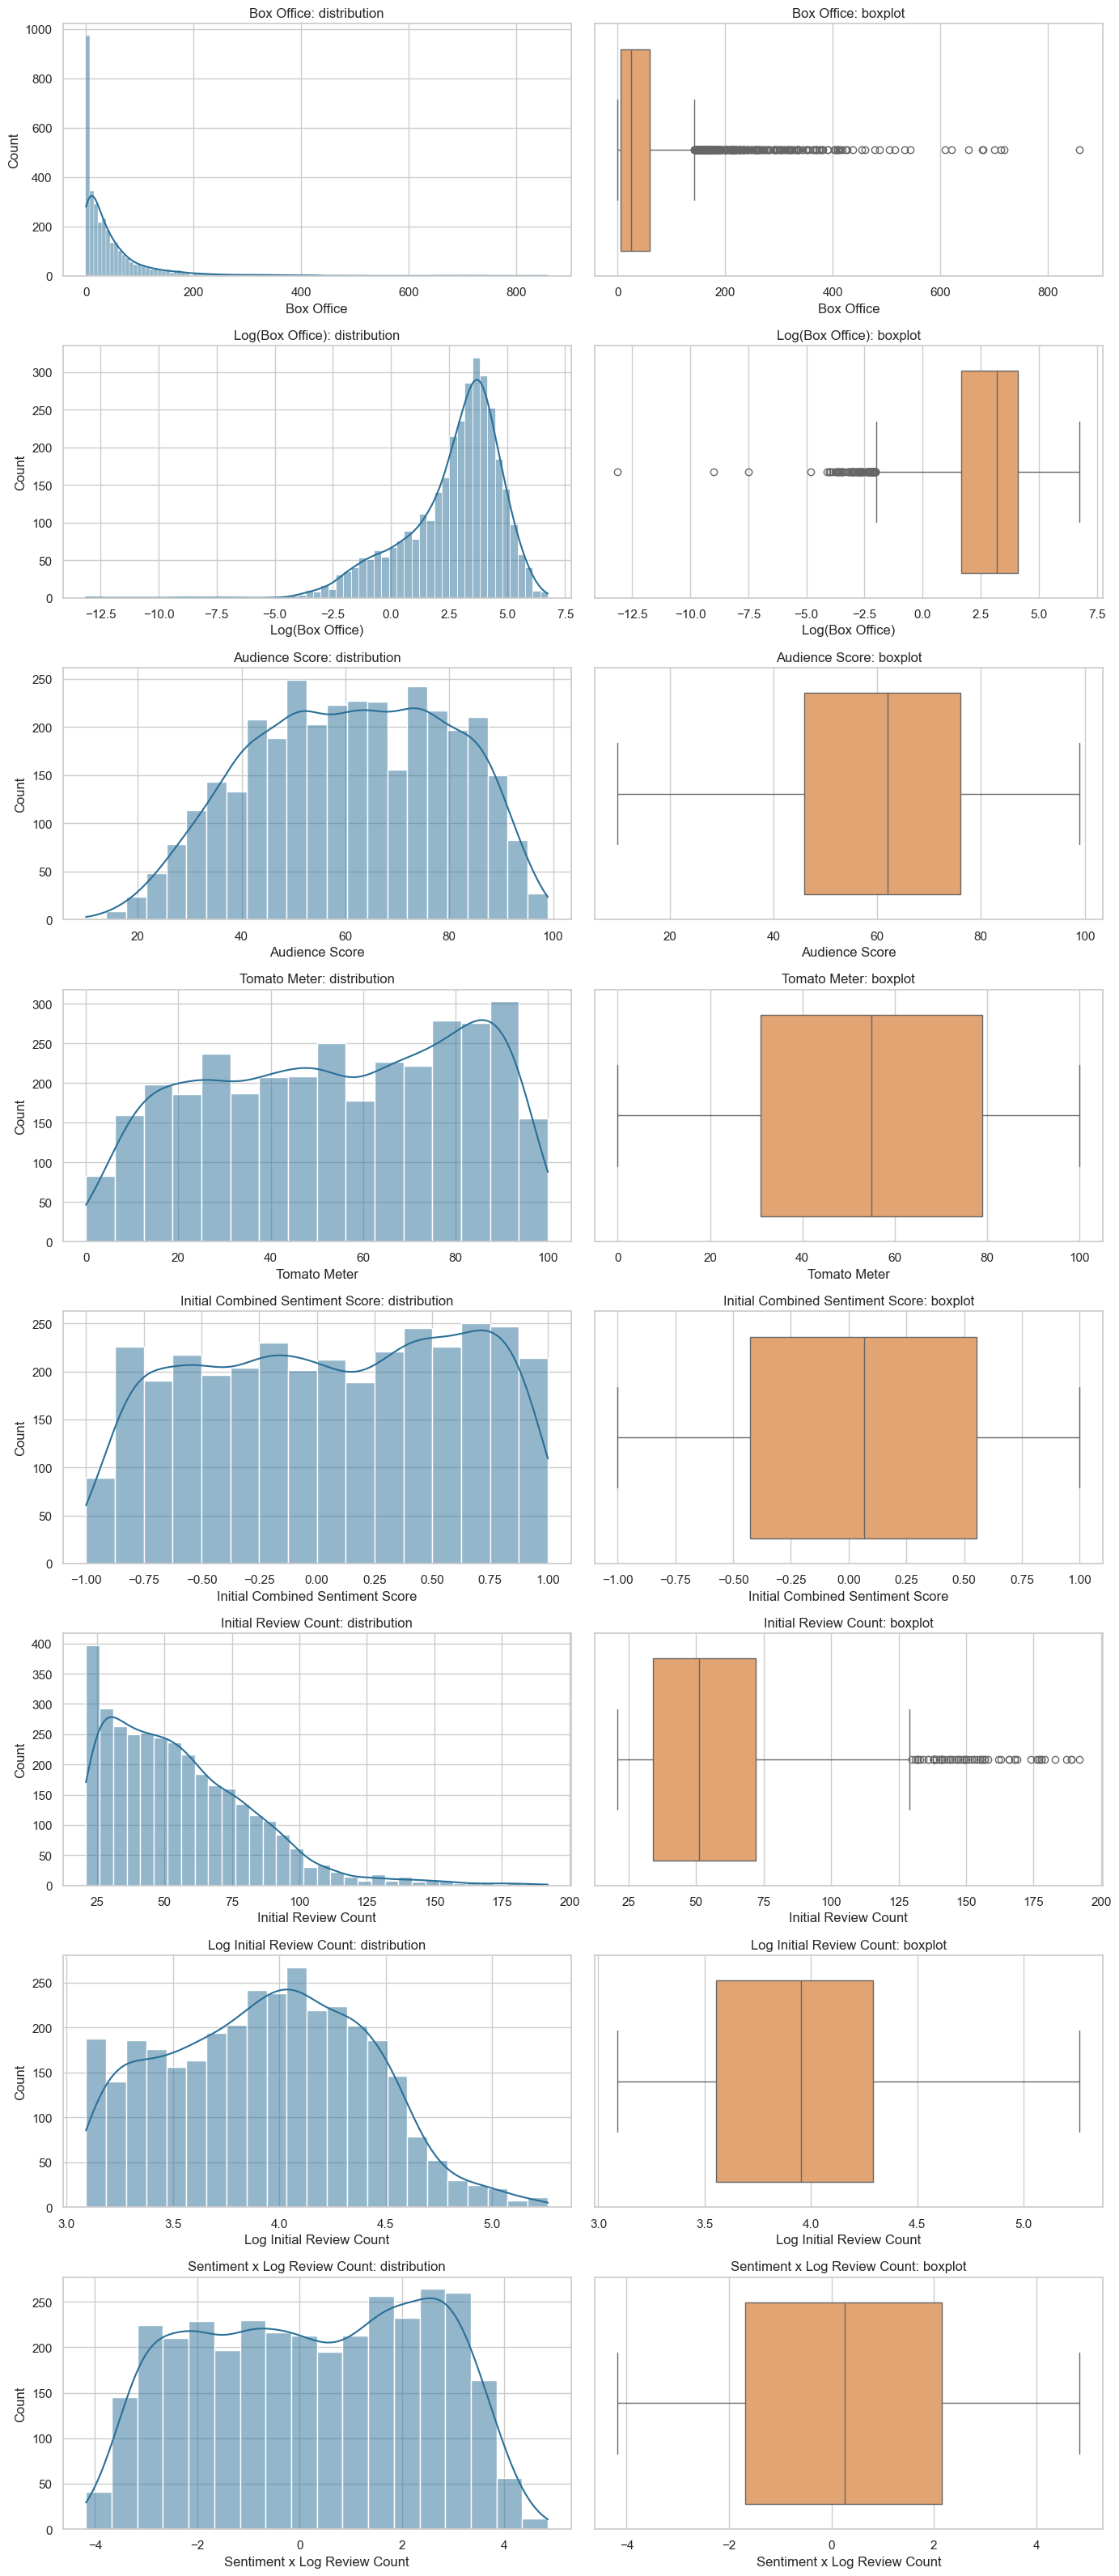

In [7]:
univariate_specs = [
    ('boxOffice', 'Box Office'),
    ('log_boxOffice', 'Log(Box Office)'),
    ('audienceScore', 'Audience Score'),
    ('tomatoMeter', 'Tomato Meter'),
    ('initial_combined_sentiment_score', 'Initial Combined Sentiment Score'),
    ('initial_review_count', 'Initial Review Count'),
    ('log_initial_review_count', 'Log Initial Review Count'),
    ('initial_sentiment_x_log_review_count', 'Sentiment x Log Review Count'),
]

fig, axes = plt.subplots(len(univariate_specs), 2, figsize=(14, 4 * len(univariate_specs)))
for row, (column, title) in enumerate(univariate_specs):
    series = analysis_df[column].dropna()
    sns.histplot(series, kde=True, ax=axes[row, 0], color='#2a6f97')
    axes[row, 0].set_title(f'{title}: distribution')
    axes[row, 0].set_xlabel(title)

    sns.boxplot(x=series, ax=axes[row, 1], color='#f4a261')
    axes[row, 1].set_title(f'{title}: boxplot')
    axes[row, 1].set_xlabel(title)

plt.tight_layout()
plt.show()


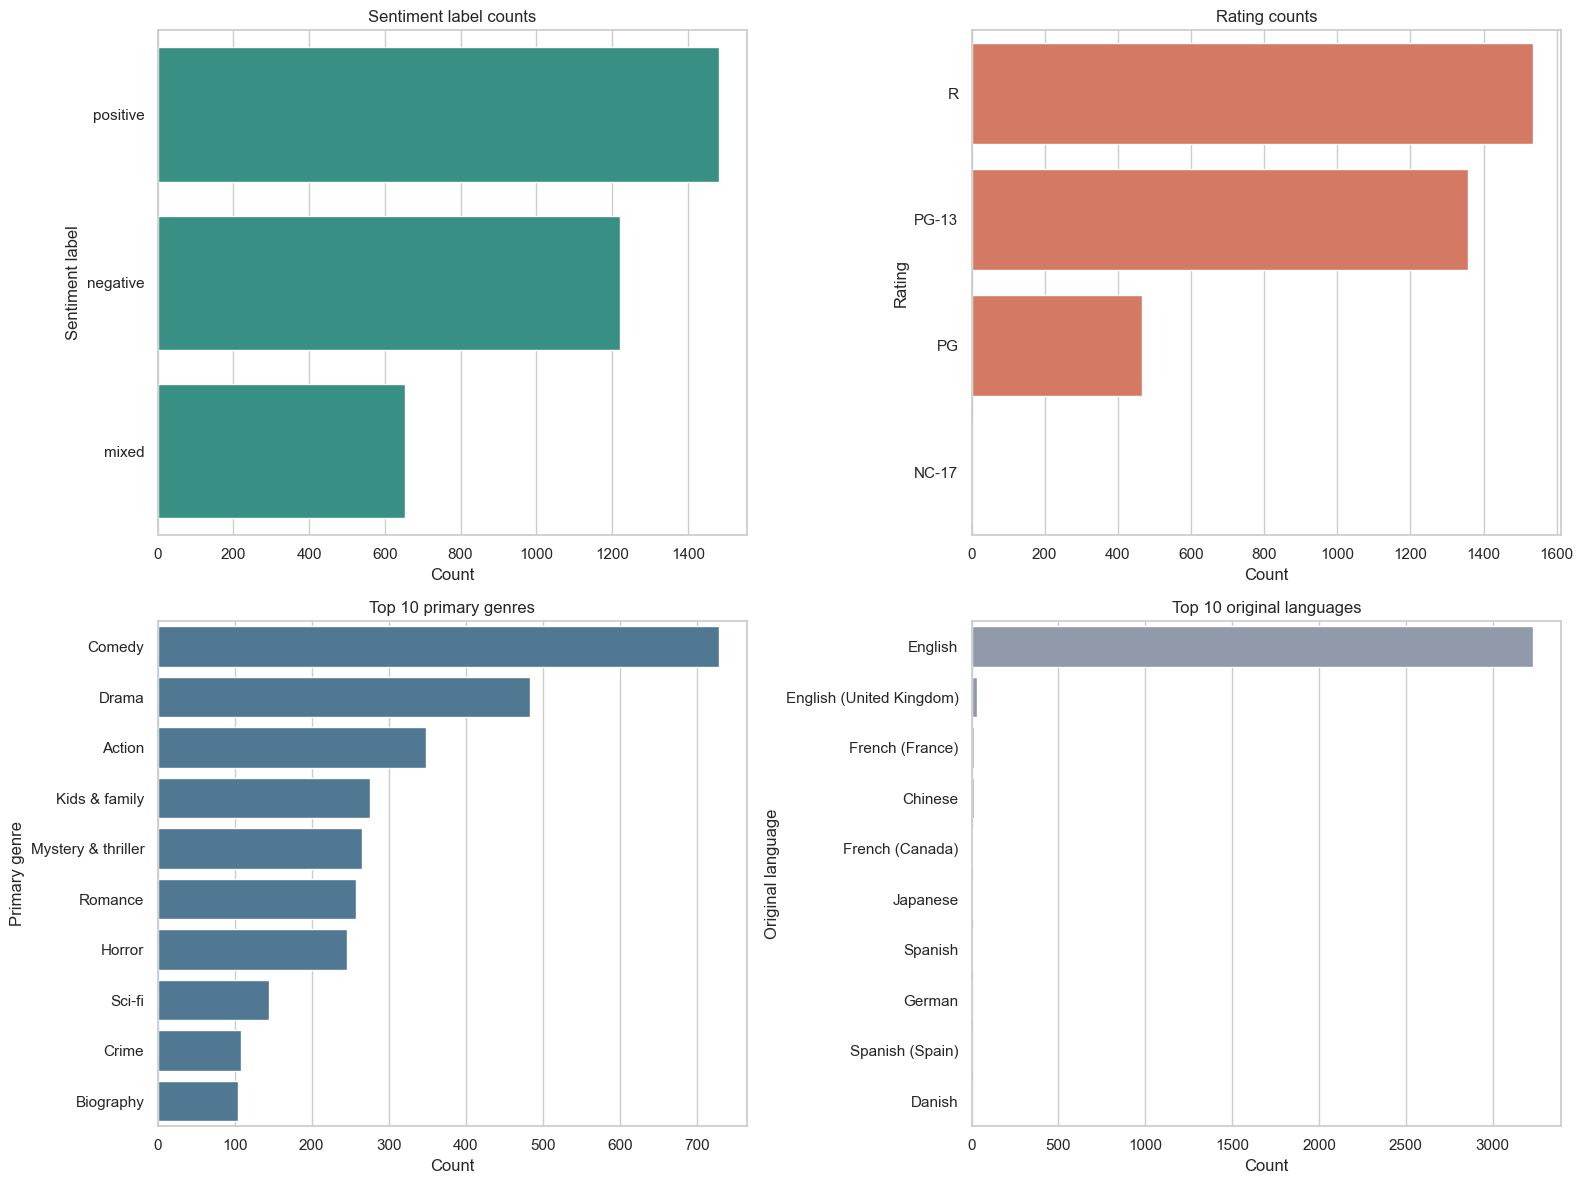

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.countplot(
    data=analysis_df,
    y='initial_combined_sentiment_label',
    order=analysis_df['initial_combined_sentiment_label'].value_counts().index,
    ax=axes[0, 0],
    color='#2a9d8f'
)
axes[0, 0].set_title('Sentiment label counts')
axes[0, 0].set_xlabel('Count')
axes[0, 0].set_ylabel('Sentiment label')

sns.countplot(
    data=analysis_df,
    y='rating',
    order=analysis_df['rating'].value_counts().index,
    ax=axes[0, 1],
    color='#e76f51'
)
axes[0, 1].set_title('Rating counts')
axes[0, 1].set_xlabel('Count')
axes[0, 1].set_ylabel('Rating')

top_genres = analysis_df['primary_genre'].value_counts().head(10).index
sns.countplot(
    data=analysis_df[analysis_df['primary_genre'].isin(top_genres)],
    y='primary_genre',
    order=top_genres,
    ax=axes[1, 0],
    color='#457b9d'
)
axes[1, 0].set_title('Top 10 primary genres')
axes[1, 0].set_xlabel('Count')
axes[1, 0].set_ylabel('Primary genre')

top_languages = analysis_df['originalLanguage'].value_counts().head(10).index
sns.countplot(
    data=analysis_df[analysis_df['originalLanguage'].isin(top_languages)],
    y='originalLanguage',
    order=top_languages,
    ax=axes[1, 1],
    color='#8d99ae'
)
axes[1, 1].set_title('Top 10 original languages')
axes[1, 1].set_xlabel('Count')
axes[1, 1].set_ylabel('Original language')

plt.tight_layout()
plt.show()


## 8. Bivariate Analysis

The next set of figures studies pairwise relationships involving the final outcome and the variables selected for the final model.


,log_boxOffice,boxOffice,audienceScore,tomatoMeter,runtimeMinutes,initial_review_count,initial_combined_sentiment_score,log_initial_review_count,initial_sentiment_x_log_review_count
log_boxOffice,1.0000,0.6336,0.1186,-0.0853,0.2181,0.5597,-0.0734,0.6127,-0.0421
boxOffice,0.6336,1.0000,0.2275,0.1338,0.3231,0.5018,0.1338,0.4753,0.1671
audienceScore,0.1186,0.2275,1.0000,0.6611,0.3517,0.1299,0.6521,0.0884,0.6554
tomatoMeter,-0.0853,0.1338,0.6611,1.0000,0.2499,0.0624,0.9816,0.0133,0.9762
runtimeMinutes,0.2181,0.3231,0.3517,0.2499,1.0000,0.3223,0.2434,0.2942,0.2574
initial_review_count,0.5597,0.5018,0.1299,0.0624,0.3223,1.0000,0.0592,0.9608,0.0987
initial_combined_sentiment_score,-0.0734,0.1338,0.6521,0.9816,0.2434,0.0592,1.0000,0.0126,0.9925
log_initial_review_count,0.6127,0.4753,0.0884,0.0133,0.2942,0.9608,0.0126,1.0000,0.0494
initial_sentiment_x_log_review_count,-0.0421,0.1671,0.6554,0.9762,0.2574,0.0987,0.9925,0.0494,1.0000


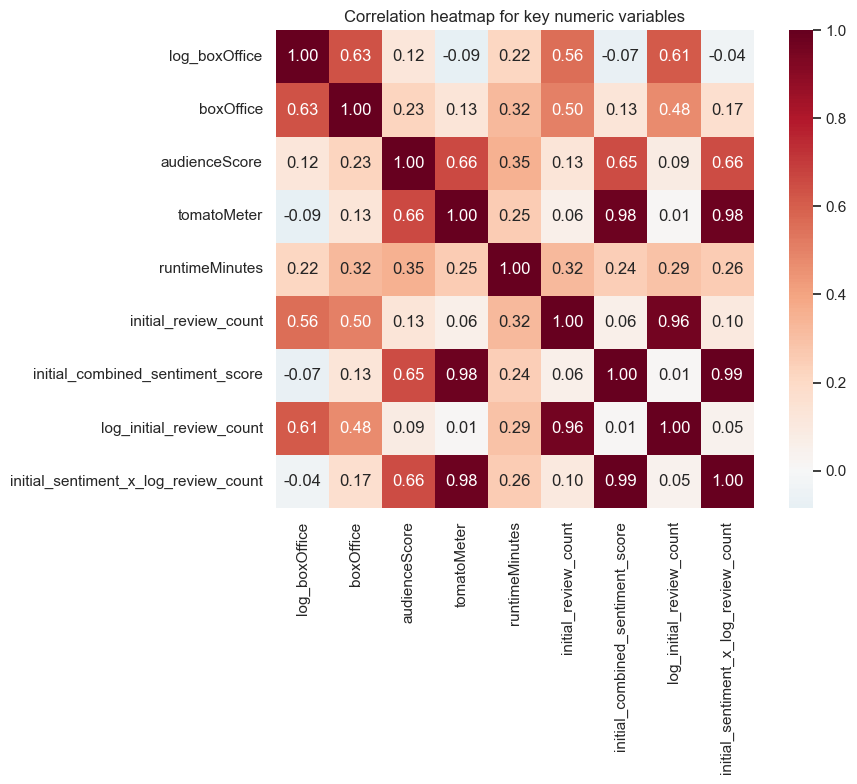

In [9]:
correlation_vars = [
    'log_boxOffice',
    'boxOffice',
    'audienceScore',
    'tomatoMeter',
    'runtimeMinutes',
    'initial_review_count',
    'initial_combined_sentiment_score',
    'log_initial_review_count',
    'initial_sentiment_x_log_review_count',
]

corr = analysis_df[correlation_vars].corr(numeric_only=True)
display(corr)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True)
plt.title('Correlation heatmap for key numeric variables')
plt.tight_layout()
plt.show()


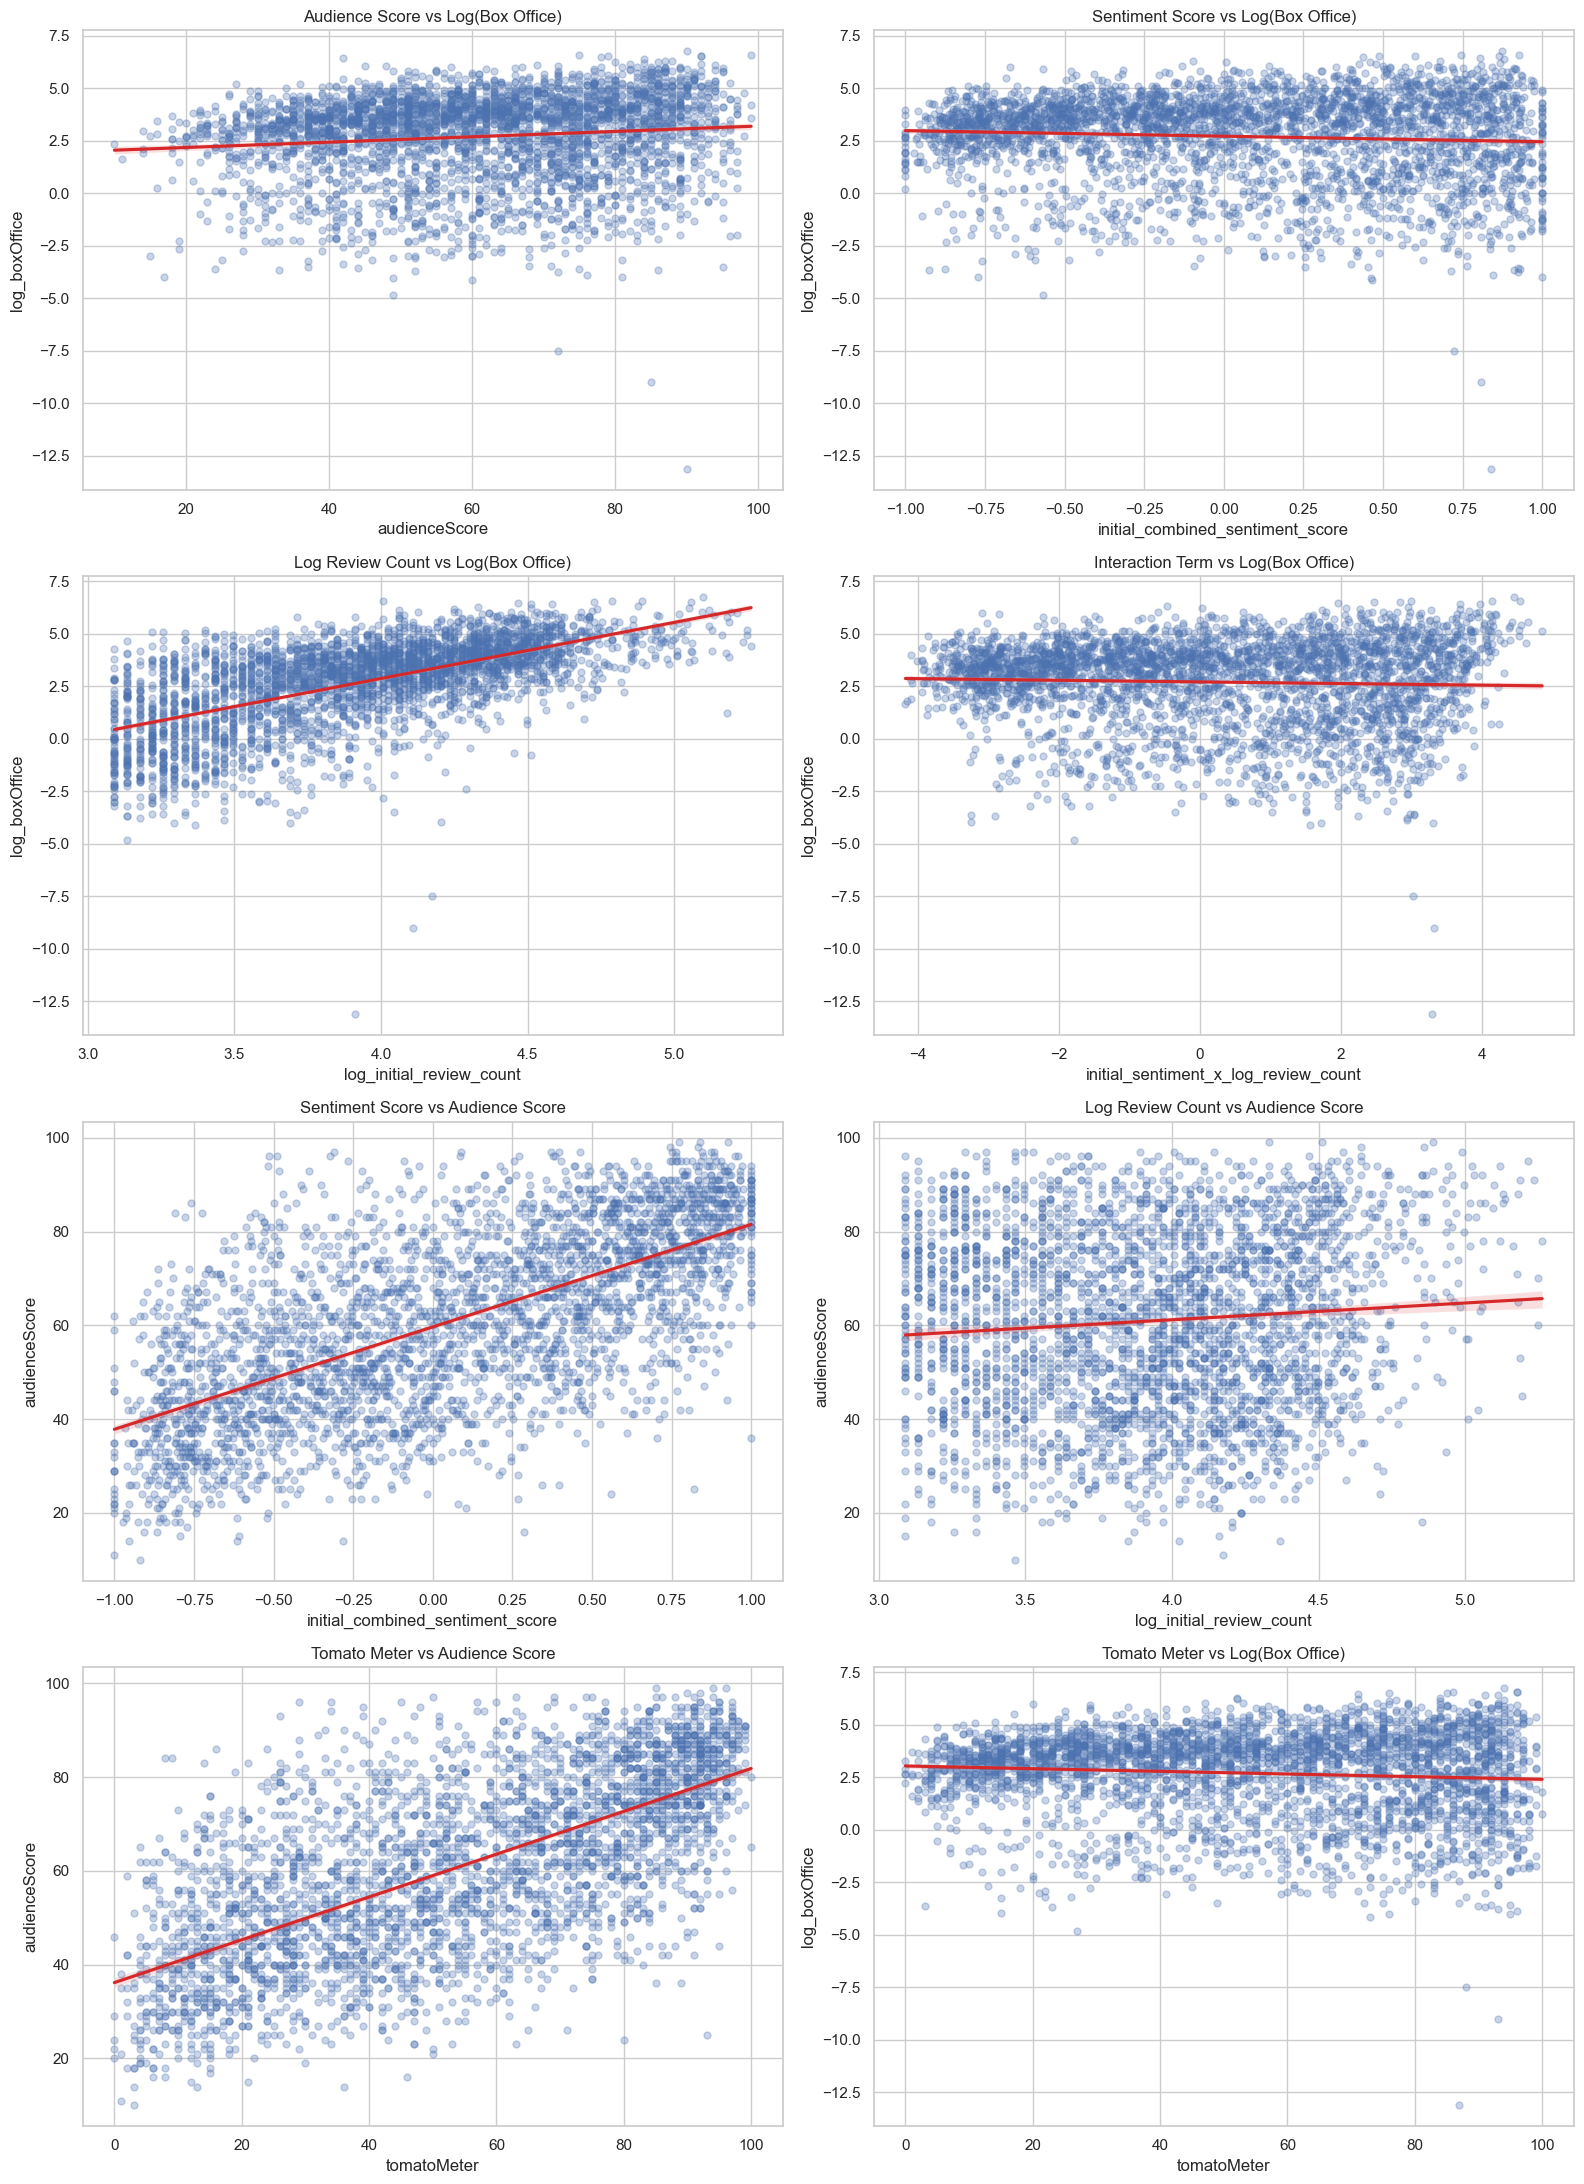

In [10]:
pair_specs = [
    ('audienceScore', 'log_boxOffice', 'Audience Score vs Log(Box Office)'),
    ('initial_combined_sentiment_score', 'log_boxOffice', 'Sentiment Score vs Log(Box Office)'),
    ('log_initial_review_count', 'log_boxOffice', 'Log Review Count vs Log(Box Office)'),
    ('initial_sentiment_x_log_review_count', 'log_boxOffice', 'Interaction Term vs Log(Box Office)'),
    ('initial_combined_sentiment_score', 'audienceScore', 'Sentiment Score vs Audience Score'),
    ('log_initial_review_count', 'audienceScore', 'Log Review Count vs Audience Score'),
    ('tomatoMeter', 'audienceScore', 'Tomato Meter vs Audience Score'),
    ('tomatoMeter', 'log_boxOffice', 'Tomato Meter vs Log(Box Office)'),
]

fig, axes = plt.subplots(4, 2, figsize=(16, 22))
for ax, (x_col, y_col, title) in zip(axes.flat, pair_specs):
    plot_df = analysis_df[[x_col, y_col]].dropna()
    sns.regplot(
        data=plot_df,
        x=x_col,
        y=y_col,
        scatter_kws={'alpha': 0.30, 's': 25},
        line_kws={'color': '#d62828'},
        ax=ax,
    )
    ax.set_title(title)

plt.tight_layout()
plt.show()


## 9. Grouped Descriptive Analysis

These summaries compare the outcome and the main predictors across meaningful groups.


In [11]:
by_sentiment = analysis_df.groupby('initial_combined_sentiment_label')[[
    'boxOffice',
    'log_boxOffice',
    'audienceScore',
    'log_initial_review_count',
    'initial_combined_sentiment_score',
    'initial_sentiment_x_log_review_count',
]].agg(['count', 'mean', 'median', 'std'])

display(by_sentiment)

analysis_df['review_count_quartile'] = pd.qcut(
    analysis_df['initial_review_count'],
    q=4,
    labels=['Q1 lowest', 'Q2', 'Q3', 'Q4 highest'],
    duplicates='drop'
)

by_review_quartile = analysis_df.groupby('review_count_quartile', observed=False)[[
    'boxOffice',
    'log_boxOffice',
    'audienceScore',
    'initial_combined_sentiment_score',
    'initial_sentiment_x_log_review_count',
]].agg(['count', 'mean', 'median'])

display(by_review_quartile)


boxOffice                          \
                                     count    mean  median     std   
initial_combined_sentiment_label                                     
mixed                                  653 52.3822 28.6000 72.6410   
negative                              1222 37.9539 25.6000 44.0419   
positive                              1482 58.9898 20.1500 96.7787   

                                 log_boxOffice                       \
                                         count   mean median    std   
initial_combined_sentiment_label                                      
mixed                                      653 2.8493 3.3534 1.9090   
negative                                  1222 2.8398 3.2426 1.6764   
positive                                  1481 2.5105 3.0057 2.3160   

                                 audienceScore                          \
                                         count    mean  median     std   
initial_combined_sentiment_label                                         
mixed                                      653 58.3415 58.0000 15.5416   
negative                                  1222 47.9984 46.0000 15.9705   
positive                                  1482 72.7915 75.0000 14.3593   

                                 log_initial_review_count                \
                                                    count   mean median   
initial_combined_sentiment_label                                          
mixed                                                 653 3.9862 4.0254   
negative                                             1222 3.9159 3.9318   
positive                                             1482 3.9310 3.9318   

                                        initial_combined_sentiment_score  \
                                    std                            count   
initial_combined_sentiment_label                                           
mixed                            0.4350                              653   
negative                         0.4168                             1222   
positive                         0.5134                             1482   

                                                         \
                                    mean  median    std   
initial_combined_sentiment_label                          
mixed                            -0.0078 -0.0101 0.1130   
negative                         -0.5663 -0.5642 0.2180   
positive                          0.6037  0.6087 0.2254   

                                 initial_sentiment_x_log_review_count          \
                                                                count    mean   
initial_combined_sentiment_label                                                
mixed                                                             653 -0.0299   
negative                                                         1222 -2.2025   
positive                                                         1482  2.3612   

                                                 
                                  median    std  
initial_combined_sentiment_label                 
mixed                            -0.0385 0.4556  
negative                         -2.1915 0.8435  
positive                          2.3727 0.9068

boxOffice                  log_boxOffice                \
                          count     mean  median         count   mean median   
review_count_quartile                                                          
Q1 lowest                   846  12.5634  2.5000           846 0.8860 0.9163   
Q2                          854  28.9549 16.8000           853 2.4463 2.8214   
Q3                          819  52.8284 33.4000           819 3.3148 3.5086   
Q4 highest                  838 106.6654 69.0000           838 4.1740 4.2341   

                      audienceScore                  \
                              count    mean  median   
review_count_quartile                                 
Q1 lowest                       846 61.0697 62.5000   
Q2                              854 58.6768 59.0000   
Q3                              819 58.5678 59.0000   
Q4 highest                      838 65.4964 66.5000   

                      initial_combined_sentiment_score                  \
                                                 count    mean  median   
review_count_quartile                                                    
Q1 lowest                                          846  0.1298  0.2262   
Q2                                                 854 -0.0112 -0.0598   
Q3                                                 819 -0.0465 -0.0744   
Q4 highest                                         838  0.1614  0.2136   

                      initial_sentiment_x_log_review_count                  
                                                     count    mean  median  
review_count_quartile                                                       
Q1 lowest                                              846  0.4239  0.7485  
Q2                                                     854 -0.0487 -0.2204  
Q3                                                     819 -0.1915 -0.3043  
Q4 highest                                             838  0.7495  0.9695

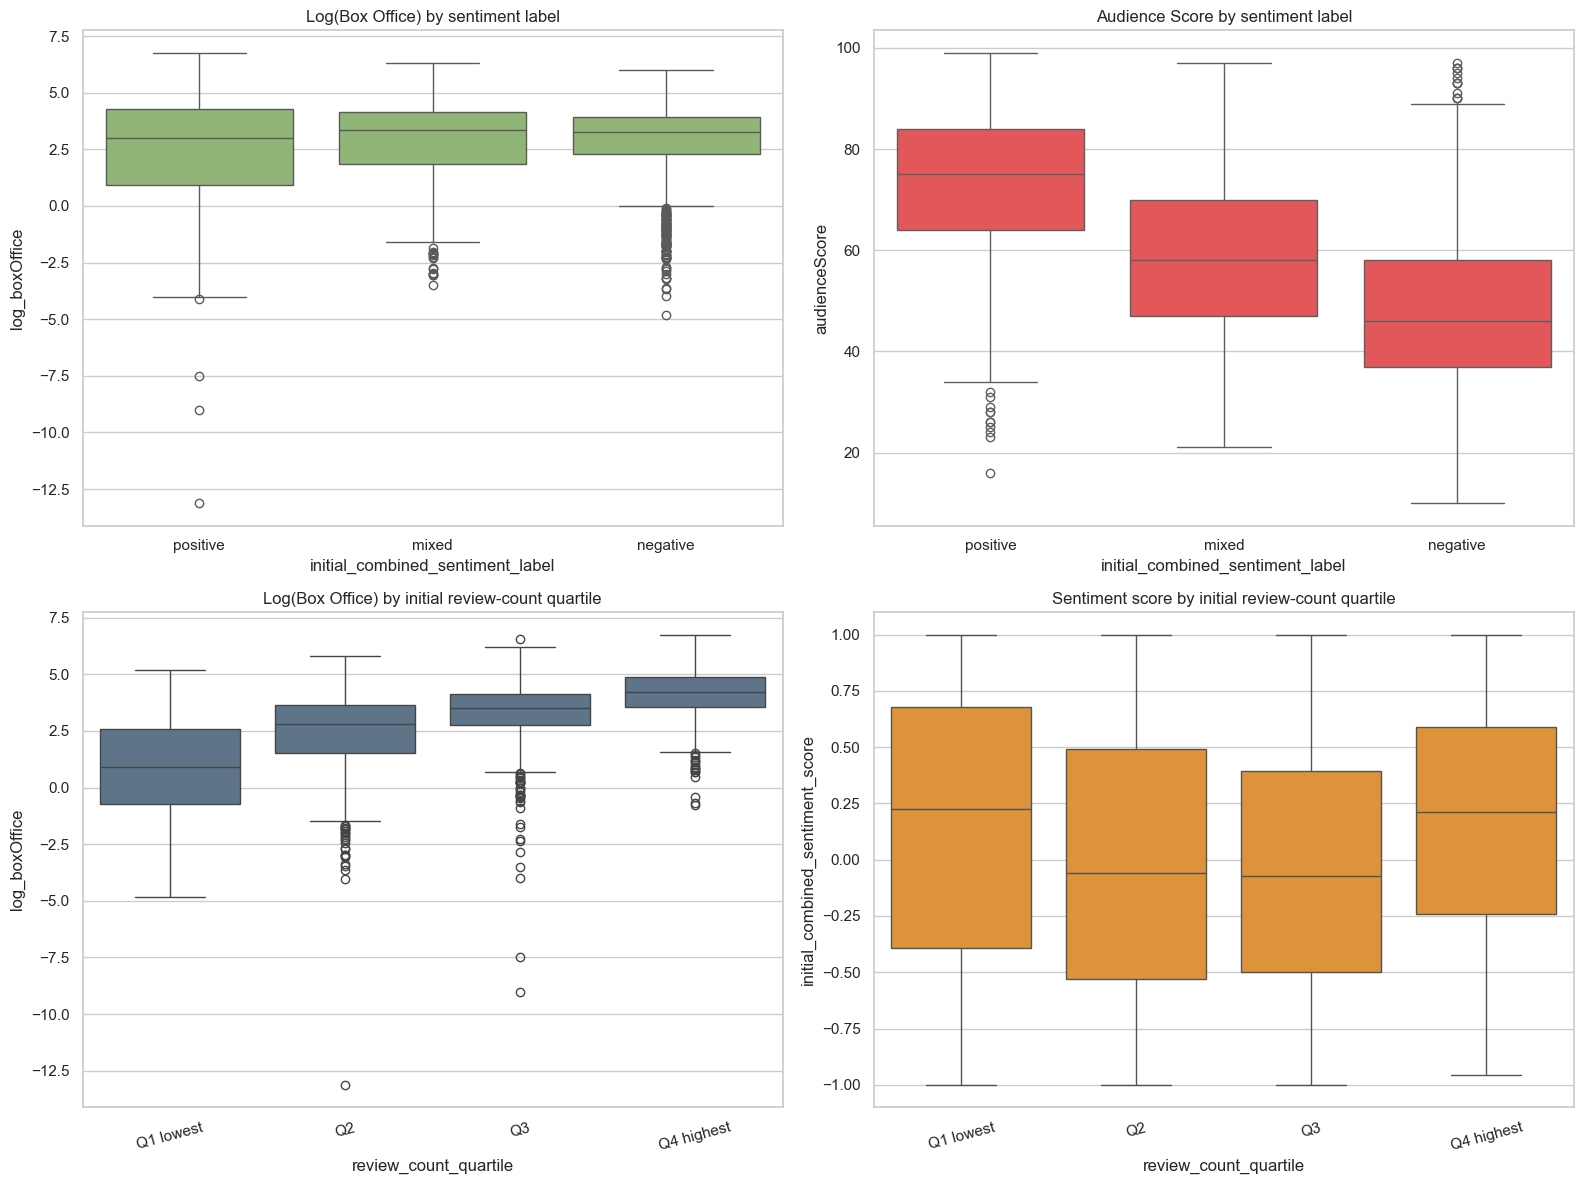

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.boxplot(data=analysis_df, x='initial_combined_sentiment_label', y='log_boxOffice', ax=axes[0, 0], color='#90be6d')
axes[0, 0].set_title('Log(Box Office) by sentiment label')

sns.boxplot(data=analysis_df, x='initial_combined_sentiment_label', y='audienceScore', ax=axes[0, 1], color='#f94144')
axes[0, 1].set_title('Audience Score by sentiment label')

sns.boxplot(data=analysis_df, x='review_count_quartile', y='log_boxOffice', ax=axes[1, 0], color='#577590')
axes[1, 0].set_title('Log(Box Office) by initial review-count quartile')
axes[1, 0].tick_params(axis='x', rotation=15)

sns.boxplot(data=analysis_df, x='review_count_quartile', y='initial_combined_sentiment_score', ax=axes[1, 1], color='#f8961e')
axes[1, 1].set_title('Sentiment score by initial review-count quartile')
axes[1, 1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


## 10. Final-Model Variable Focus

This section isolates the outcome and the exact predictors chosen for the final model specification.


,count,mean,std,min,25%,50%,75%,max
log_boxOffice,"3,356.0000",2.6963,2.0309,-13.1224,1.6487,3.1946,4.0943,6.7551
audienceScore,"3,356.0000",60.9479,18.8399,10.0000,46.0000,62.0000,76.0000,99.0000
initial_combined_sentiment_score,"3,356.0000",0.0587,0.5626,-1.0000,-0.4286,0.0667,0.5556,1.0000
log_initial_review_count,"3,356.0000",3.9362,0.4659,3.0910,3.5553,3.9512,4.2905,5.2627
initial_sentiment_x_log_review_count,"3,356.0000",0.2343,2.1990,-4.1744,-1.6870,0.2575,2.1631,4.8481


,log_boxOffice,audienceScore,initial_combined_sentiment_score,log_initial_review_count,initial_sentiment_x_log_review_count
log_boxOffice,1.0000,0.1186,-0.0734,0.6127,-0.0421
audienceScore,0.1186,1.0000,0.6520,0.0884,0.6553
initial_combined_sentiment_score,-0.0734,0.6520,1.0000,0.0126,0.9925
log_initial_review_count,0.6127,0.0884,0.0126,1.0000,0.0494
initial_sentiment_x_log_review_count,-0.0421,0.6553,0.9925,0.0494,1.0000


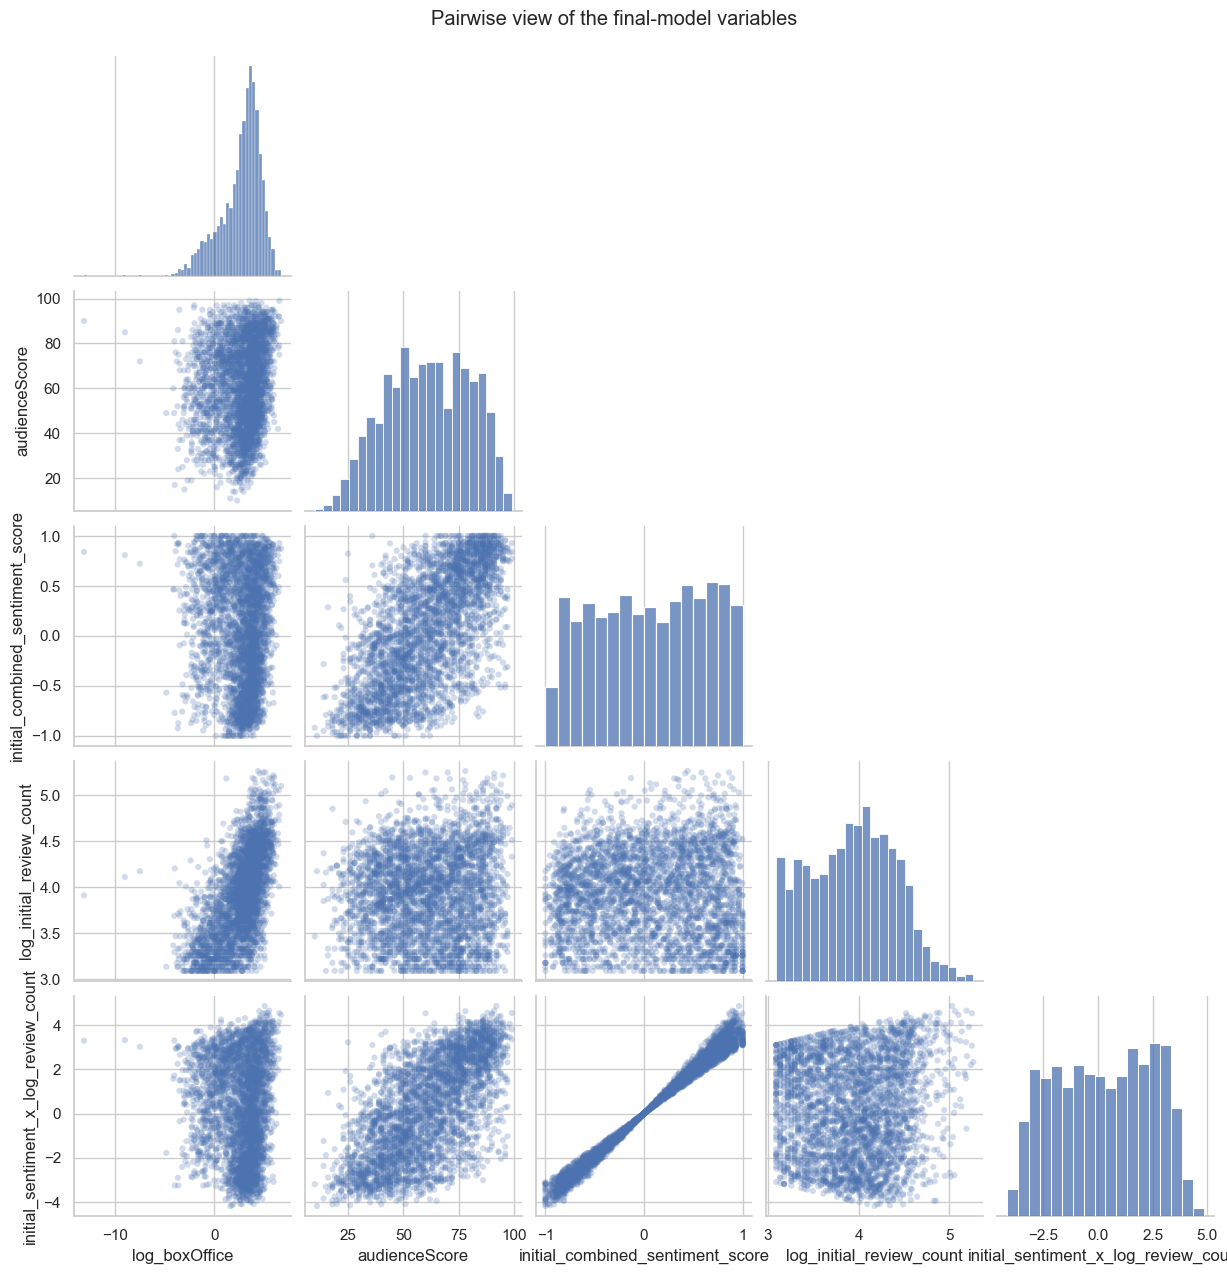

In [13]:
final_model_df = analysis_df[['log_boxOffice'] + FINAL_MODEL_VARS].dropna()

display(final_model_df.describe(percentiles=[0.25, 0.5, 0.75]).T)
display(final_model_df.corr())

sns.pairplot(
    final_model_df,
    corner=True,
    diag_kind='hist',
    plot_kws={'alpha': 0.25, 's': 20, 'edgecolor': 'none'},
)
plt.suptitle('Pairwise view of the final-model variables', y=1.02)
plt.show()
